In [18]:
import pandas as pd
from pathlib import Path
import numpy as np

In [19]:
stock_list = pd.read_csv('Eastmoney_report_pdf_download/HS300.csv',encoding='utf-8')


In [20]:
df_full_trading_data = pd.DataFrame()

In [21]:
import pandas as pd
from pathlib import Path

def process_single_stock(code, folder="trading_data"):
    """
    Process a single stock CSV file and return a DataFrame
    - Input: stock code (int or str), folder path
    - Output: DataFrame with index as trading date and column name as stock code
    """
    if code == '沪深300':
        codes_padded = code
    else:
        codes_padded = str(code).zfill(6)  # Pad to 6 digits
    path = Path(folder) / f"{codes_padded}.csv"

    if not path.exists():
        print(f"File not found: {path}")
        return None

    temp = pd.read_csv(path, encoding='utf-8')
    temp = temp[['交易日期', '涨跌幅(%)']]
    # temp['交易日期'] = pd.to_datetime(temp['交易日期'])
    temp = temp.drop_duplicates(subset=['交易日期'])  # Remove duplicates
    temp = temp.rename(columns={'涨跌幅(%)': codes_padded})
    temp = temp.set_index('交易日期')

    return temp


In [22]:
all_data = []

for code in stock_list['股票代码']:
    df = process_single_stock(code, folder="trading_data")
    if df is not None:
        all_data.append(df)
all_data.append(process_single_stock('沪深300'))
# 拼接成大表
big_table = pd.concat(all_data, axis=1, join='outer').reset_index().sort_values(by='交易日期')
big_table['交易日期'] = pd.to_datetime(big_table['交易日期'], format='%Y%m%d')
big_table = big_table.dropna(subset=['交易日期'])
big_table.to_csv("all_stock_returns.csv", index=False, encoding="utf-8")


In [23]:
import pandas as pd

big_table = pd.read_csv("all_stock_returns.csv", encoding="utf-8")
if big_table is None:
	raise ValueError("Cannot read all_stock_returns.csv file")	

# Convert all return columns to numeric
for col in big_table.columns:
	if col != '交易日期':
		big_table[col] = pd.to_numeric(big_table[col], errors='coerce')

big_table = big_table.fillna(0)


# Convert to daily returns (decimal)
returns = big_table.drop(columns=['交易日期']) / 100.0

# Calculate daily compounding factors
factors = 1 + returns
factors['交易日期'] = big_table['交易日期']

print(factors.shape)


(6283, 302)


C:\Users\Administrator\AppData\Local\Temp\ipykernel_316740\1576717755.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  factors['交易日期'] = big_table['交易日期']


In [24]:
# Convert trading date to quarterly period
factors['交易日期'] = pd.to_datetime(factors['交易日期']).dt.to_period("Q")

# Aggregate by quarter: product - 1

quarterly_returns = (factors.groupby('交易日期').prod() - 1).reset_index()

print(quarterly_returns)


       交易日期    688981    688599    688506    688472    688396    688303  \
0    2000Q1  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
1    2000Q2  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
2    2000Q3  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
3    2000Q4  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
4    2001Q1  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
..      ...       ...       ...       ...       ...       ...       ...   
99   2024Q4  0.577263 -0.139157 -0.020386 -0.100928  0.000845 -0.078631   
100  2025Q1 -0.055909 -0.127979  0.211650 -0.225319 -0.050645 -0.196355   
101  2025Q2 -0.012988 -0.136660  0.274674 -0.059611  0.054050  0.098967   
102  2025Q3  0.589316  0.195455  0.267392  0.483416  0.177905  0.347561   
103  2025Q4 -0.185186 -0.019570 -0.030244  0.185268 -0.048617 -0.045248   

       688271    688256    688223  ...    000338    000333    000301  \
0    0.000000  0.000000  0.

In [25]:
quarterly_excess_returns = quarterly_returns.drop(columns=['交易日期']).sub(
    quarterly_returns['沪深300'], axis=0
)
quarterly_excess_returns['交易日期'] = quarterly_returns['交易日期']

In [26]:
quarterly_excess_returns

,688981,688599,688506,688472,688396,688303,688271,688256,688223,688187,...,000333,000301,000166,000157,000100,000063,000002,000001,沪深300,交易日期
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.191650,0.375095,0.052625,0.0,2000Q1
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.940137,0.000000,0.000000,0.000000,0.040490,0.064532,-0.013114,0.0,2000Q2
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,-0.048142,0.000000,0.000000,0.000000,0.225782,-0.074695,-0.064696,0.0,2000Q3
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.085481,0.000000,0.938983,0.000000,0.047119,0.131582,-0.037339,0.0,2000Q4
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.007599,0.000000,-0.056387,0.000000,-0.052326,0.081252,0.117094,0.0,2001Q1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99,0.577263,-0.139157,-0.020386,-0.100928,0.000845,-0.078631,-0.011560,1.275557,-0.192964,-0.097044,...,-0.011047,-0.115304,-0.061188,-0.046174,0.098254,0.296952,-0.253090,-0.020811,0.0,2024Q4
100,-0.055909,-0.127979,0.211650,-0.225319,-0.050645,-0.196355,-0.034887,-0.053193,-0.088611,-0.013566,...,0.043601,0.009744,-0.078508,0.040111,-0.115308,-0.152968,-0.028923,-0.037608,0.0,2025Q1
101,-0.012988,-0.136660,0.274674,-0.059611,0.054050,0.098967,0.047135,-0.034511,-0.199076,-0.097737,...,-0.035807,0.004829,0.018255,-0.038568,-0.026966,-0.031889,-0.089364,0.105526,0.0,2025Q2
102,0.589316,0.195455,0.267392,0.483416,0.177905,0.347561,0.188261,1.202814,0.071288,0.262268,...,0.006371,0.141658,0.071661,0.150938,0.006293,0.404741,0.073207,-0.060481,0.0,2025Q3


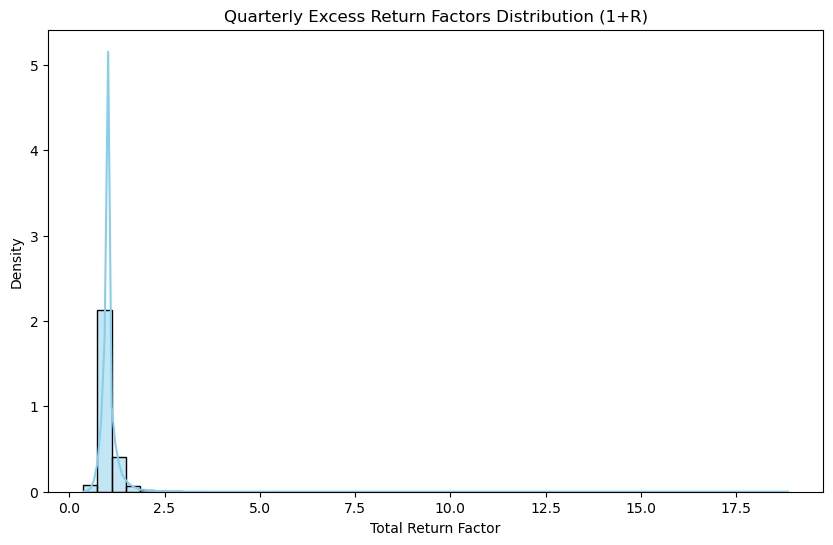

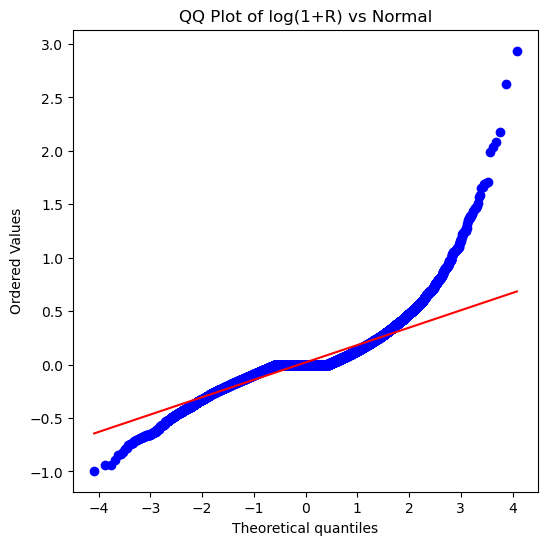

  Distribution                                             Params   KS stat  \
0       Normal          (0.03952533082459204, 0.2711866199802055)  0.230255   
1    Lognormal  (0.2529539590679434, 0.30528559993211307, 0.70...  0.197100   
2            t  (0.2658922347443587, 2.4062150837580504e-16, 3...  0.332985   
3      Laplace                          (0.0, 0.1105051344358721)  0.209061   

   KS p-value  
0         0.0  
1         0.0  
2         0.0  
3         0.0  


In [ ]:
# Analyze distribution characteristics of quarterly excess returns

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Assume quarterly_excess_returns is your DataFrame
# Keep only numeric columns
numeric_df = quarterly_excess_returns.select_dtypes(include=[np.number])

# Flatten all values and remove NaN
flattened = numeric_df.values.flatten()
flattened = flattened[~np.isnan(flattened)]

# Convert to total return factor (1+return), ensure positive values
# Note: if return < -100%, it will result in negative values, need to check first
total_return_factor = 1 + flattened
total_return_factor = total_return_factor[total_return_factor > 0]

# ===========================
# 1. Plot histogram + KDE
# ===========================
plt.figure(figsize=(10,6))
sns.histplot(total_return_factor, bins=50, kde=True, stat="density", color="skyblue")
plt.title("Quarterly Excess Return Factors Distribution (1+R)")
plt.xlabel("Total Return Factor")
plt.ylabel("Density")
plt.show()

# ===========================
# 2. QQ plot vs Normal (for log(total_return_factor))
# ===========================
plt.figure(figsize=(6,6))
stats.probplot(np.log(total_return_factor), dist="norm", plot=plt)
plt.title("QQ Plot of log(1+R) vs Normal")
plt.show()

# ===========================
# 3. Fit different distributions and perform KS test
# ===========================
distributions = {
    "Normal": stats.norm,
    "Lognormal": stats.lognorm,
    "t": stats.t,
    "Laplace": stats.laplace
}

fit_results = []
for name, dist in distributions.items():
    try:
        # Use original returns for Normal/t/Laplace
        data_to_fit = flattened if name != "Lognormal" else total_return_factor
        params = dist.fit(data_to_fit)
        ks_stat, ks_p = stats.kstest(data_to_fit, dist.name, args=params)
        fit_results.append([name, params, ks_stat, ks_p])
    except Exception as e:
        fit_results.append([name, str(e), None, None])

# Convert to DataFrame and output results
results_df = pd.DataFrame(fit_results, columns=["Distribution", "Params", "KS stat", "KS p-value"])
print(results_df)


In [ ]:
# Based on analysis results, choose Lognormal distribution for 5-class labeling


import numpy as np
import pandas as pd

def label_quarterly_lognormal_quantile(df, eps=1e-6, lower_pct=0.1, upper_pct=99.9):
    labels = []

    for quarter, g in df.groupby("交易日期"):
        numeric_df = g.select_dtypes(include=[np.number])
        flattened = numeric_df.values.flatten()
        flattened = flattened[~np.isnan(flattened)]
        flattened = flattened[np.abs(flattened) > eps]  # Ignore near-zero values

        # Convert to total return factor (must be positive)
        total_return = 1 + flattened
        total_return = total_return[total_return > 0]

        # If insufficient samples, set to neutral
        if len(total_return) < 50:
            g_labels = pd.DataFrame(2, index=g.index, columns=numeric_df.columns)
        else:
            # Winsorize to remove extremes
            lower, upper = np.percentile(total_return, [lower_pct, upper_pct])
            total_return = np.clip(total_return, lower, upper)

            # Fit lognormal → log returns approximately normal
            log_ret = np.log(total_return)

            # Use quantiles to divide
            q20, q40, q60, q80 = np.percentile(log_ret, [20, 40, 60, 80])

            def label_5class(x):
                if pd.isna(x):
                    return np.nan
                elif abs(x) <= eps:
                    return 2  # Non-tradable → Neutral
                r = 1 + x
                if r <= 0:
                    return 2  # Invalid value → Neutral
                log_r = np.log(r)
                if log_r < q20:
                    return 0
                elif log_r < q40:
                    return 1
                elif log_r < q60:
                    return 2
                elif log_r < q80:
                    return 3
                else:
                    return 4

            g_labels = numeric_df.map(label_5class)

        g_labels["交易日期"] = g["交易日期"]
        labels.append(g_labels)

    return pd.concat(labels)

# Usage
labels_5class = label_quarterly_lognormal_quantile(
    quarterly_excess_returns, eps=1e-6, lower_pct=0.1, upper_pct=99.9
)


In [ ]:
# Based on analysis results, choose Lognormal distribution for 3-class labeling

import numpy as np
import pandas as pd

def label_quarterly_lognormal_quantile_3class(df, eps=1e-6, lower_pct=0.1, upper_pct=99.9):
    labels = []

    for quarter, g in df.groupby("交易日期"):
        numeric_df = g.select_dtypes(include=[np.number])
        flattened = numeric_df.values.flatten()
        flattened = flattened[~np.isnan(flattened)]
        flattened = flattened[np.abs(flattened) > eps]  # Ignore near-zero values

        # Convert to total return factor (must be positive)
        total_return = 1 + flattened
        total_return = total_return[total_return > 0]

        # If insufficient samples, set to neutral
        if len(total_return) < 50:
            g_labels = pd.DataFrame(1, index=g.index, columns=numeric_df.columns)
        else:
            # Winsorize to remove extremes
            lower, upper = np.percentile(total_return, [lower_pct, upper_pct])
            total_return = np.clip(total_return, lower, upper)

            # Fit lognormal → log returns approximately normal
            log_ret = np.log(total_return)

            # Use quantiles to divide into three classes
            q33, q67 = np.percentile(log_ret, [33, 67])

            def label_3class(x):
                if pd.isna(x):
                    return np.nan
                elif abs(x) <= eps:
                    return 1  # Non-tradable → Neutral
                r = 1 + x
                if r <= 0:
                    return 1  # Invalid value → Neutral
                log_r = np.log(r)
                if log_r < q33:
                    return 0  # Negative class
                elif log_r < q67:
                    return 1  # Neutral
                else:
                    return 2  # Positive class

            g_labels = numeric_df.map(label_3class)

        g_labels["交易日期"] = g["交易日期"]
        labels.append(g_labels)

    return pd.concat(labels)

# Usage
labels_3class = label_quarterly_lognormal_quantile_3class(
    quarterly_excess_returns, eps=1e-6, lower_pct=0.1, upper_pct=99.9
)


In [ ]:
# Based on analysis results, use direct regression labels

import numpy as np
import pandas as pd

def label_quarterly_regression(df, eps=1e-6, lower_pct=0.1, upper_pct=99.9):
    labels = []

    for quarter, g in df.groupby("交易日期"):
        numeric_df = g.select_dtypes(include=[np.number])
        flattened = numeric_df.values.flatten()
        flattened = flattened[~np.isnan(flattened)]
        flattened = flattened[np.abs(flattened) > eps]  # Ignore near-zero values

        # Convert to total return factor (must be positive)
        total_return = 1 + flattened
        total_return = total_return[total_return > 0]

        # If insufficient samples, return NaN
        if len(total_return) < 50:
            g_labels = pd.DataFrame(np.nan, index=g.index, columns=numeric_df.columns)
        else:
            # Winsorize to remove extremes
            lower, upper = np.percentile(total_return, [lower_pct, upper_pct])
            clipped = np.clip(1 + numeric_df, lower, upper) - 1  # Keep original excess return scale

            # Use directly as regression labels
            g_labels = clipped

        g_labels["交易日期"] = g["交易日期"]
        labels.append(g_labels)

    return pd.concat(labels)

# Usage
labels_regression = label_quarterly_regression(
    quarterly_excess_returns, eps=1e-6, lower_pct=0.1, upper_pct=99.9
)


In [14]:
labels_regression.to_csv("labels_regression.csv", index=False, encoding="utf-8")

In [ ]:
import pandas as pd

# Assume labels_5class has been generated and contains trading date column
# Count only label columns, excluding trading date
label_counts = labels_5class.drop(columns=['交易日期']).stack().value_counts(normalize=True)

# Convert to percentage format
label_percentages = (label_counts * 100).round(2)

print("Label distribution (%):")
print(label_percentages)


各标签百分比：
2    49.94
4    12.62
0    12.57
3    12.44
1    12.44
Name: proportion, dtype: float64


In [ ]:
import pandas as pd

# Assume labels_3class has been generated and contains trading date column
# Count only label columns, excluding trading date
label_counts = labels_3class.drop(columns=['交易日期']).stack().value_counts(normalize=True)

# Convert to percentage format
label_percentages = (label_counts * 100).round(2)

print("Label distribution (%):")
print(label_percentages)


各标签百分比：
1    58.65
2    20.68
0    20.67
Name: proportion, dtype: float64


In [17]:
labels_5class.to_csv("labels_5class.csv", index=False, encoding="utf-8")
labels_3class.to_csv("labels_3class.csv", index=False, encoding="utf-8")
labels_regression.to_csv("labels_regression.csv", index=False, encoding="utf-8")